In [2]:
from RT_v1 import *


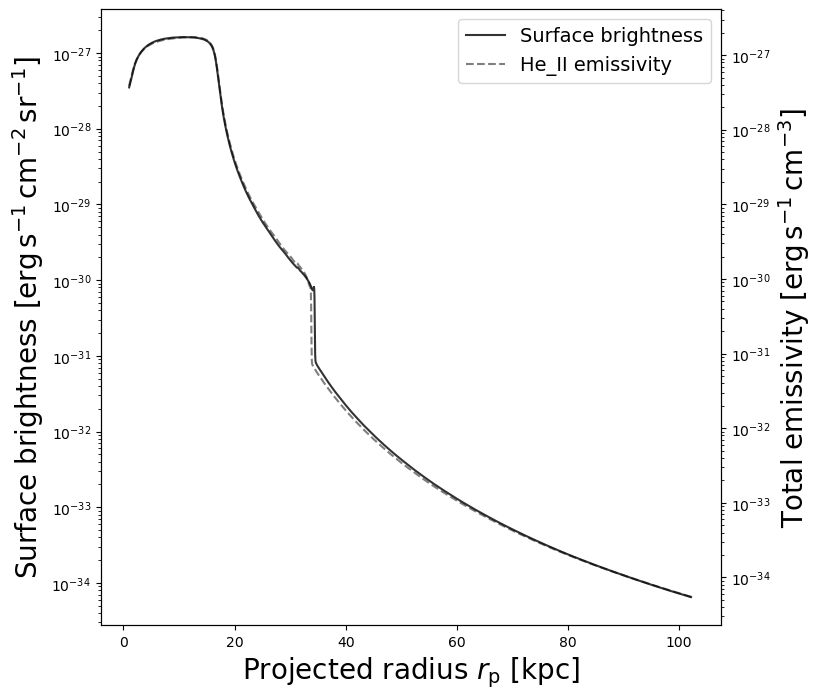

In [9]:
Lumin = 44.0 # 37.0 - 44.0 + 41.5, 42.5, 43.5 and 44.5
metals = 1.0 # 0.001 - 10.0
Column_density_order = 22.0 # 18.0 - 25.0
n_h_40 = (10**Column_density_order) / (40*kpc)

atom = 'CIV'

cloudy_data= CLOUDY_data_path_new(Lumin,metals,Column_density_order)
emis_CIV, emis_HeII = cloudy_data['emis_CIV'], cloudy_data['emis_HeII']
nden_CIV, nden_HeII = cloudy_data['nden_CIV'], cloudy_data['nden_HeII']
Te , ne, radius, radius_kpc =  cloudy_data['Te'],  cloudy_data['ne'], cloudy_data['radius'], cloudy_data['radius_kpc']

dr = abs(radius_kpc[0]-radius_kpc[1])

atom = 'HeII'
radius_p, SB_HeII= spatial_distribution_CLOUDY(atom,Lumin, metals, Column_density_order)

fig = plt.figure(1,figsize=(8,8))
ax = plt.subplot()
ax.plot(radius,emis_HeII,linestyle='-',alpha = 0.8, color = 'k',label='Surface brightness')
ax.set_yscale('log')
ax.set_xlabel(r'Projected radius $r_{\rm p}$ [kpc]',fontsize=20)
ax.set_ylabel(r'Surface brightness $\rm [erg \, s^{-1} \, cm^{-2}\,sr^{-1}]$',fontsize=20)

# ax.set_ylim(ymax=1e-4,ymin=1e-13)
# ax.axhline(y=1,xmin=0,xmax=1,linestyle='--',color='k',alpha=0.5,label='He_II emissivity')


ax1 = ax.twinx()

cloudy_data= CLOUDY_data_path(Lumin,metals,Column_density_order)
emis_CIV, emis_HeII = cloudy_data['emis_CIV'], cloudy_data['emis_HeII']
nden_CIV, nden_HeII = cloudy_data['nden_CIV'], cloudy_data['nden_HeII']
Te , ne, radius, radius_kpc =  cloudy_data['Te'],  cloudy_data['ne'], cloudy_data['radius'], cloudy_data['radius_kpc']

dr = abs(radius_kpc[0]-radius_kpc[1])

atom = 'HeII'
radius_p, SB_HeII= spatial_distribution_CLOUDY(atom,Lumin, metals, Column_density_order)

ax1.plot(radius, emis_HeII,linestyle='--',color='k',alpha=0.5,label='He_II emissivity')
ax1.set_ylabel(r'Total emissivity $\rm [erg \, s^{-1} \, cm^{-3}]$',fontsize=20)
ax1.set_yscale('log')

# 기존 두 줄의 plt.legend() 제거하고 아래로 교체

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax1.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=14)

